<a href="https://colab.research.google.com/github/AditiNayak-S/MLT3011_Cloud-Infrastructure-Failure-Prediction/blob/main/notebooks/Machine_LearningTechniques_Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Techniques

## Lab 3: Linear and Multiple Linear Regression


### Lab Objectives

- Prepare a cloud infrastructure monitoring dataset for regression analysis.
- Implement a Simple Linear Regression model.
- Implement a Multiple Linear Regression model.
- Compare the predictive performance of both regression models.
- Evaluate the models using standard regression metrics.
- Visualize and interpret the regression results.

## Importing Required Libraries

The following libraries are used for data manipulation, visualization, feature engineering, regression modelling, and performance evaluation.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import glob
import zipfile

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Required libraries imported successfully.")

Required libraries imported successfully.


In [ ]:
import matplotlib.pyplot as plt

# Set global rcParams for black background and white text
plt.rcParams['figure.facecolor'] = 'black'
plt.rcParams['axes.facecolor'] = 'black'
plt.rcParams['text.color'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['axes.titlecolor'] = 'white'
plt.rcParams['legend.labelcolor'] = 'white'
plt.rcParams['grid.color'] = '#444444' # Darker grid lines for contrast
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.linewidth'] = 0.5

print("Plotting style set to black background with white text.")

Plotting style set to black background with white text.


## Uploading and Extracting the Project Datasets

The Cloud Infrastructure Failure Prediction System utilizes two real-world datasets. Both datasets are uploaded in ZIP format and extracted into the Google Colab environment to access the required cloud monitoring files.

In [ ]:
uploaded = files.upload()

Saving CIFPS - DATASET A.zip to CIFPS - DATASET A.zip
Saving CIFPS - DATASET B.zip to CIFPS - DATASET B.zip


In [ ]:
uploaded_files = list(uploaded.keys())

print("Uploaded Files:\n")

for file in uploaded_files:
    print(file)

Uploaded Files:

CIFPS - DATASET A.zip
CIFPS - DATASET B.zip


In [ ]:
for zip_file in uploaded_files:
    with zipfile.ZipFile(zip_file, "r") as zip_ref:
        zip_ref.extractall()

print("Datasets extracted successfully.")

Datasets extracted successfully.


## Configuring Dataset Paths

The root directories of Dataset A and Dataset B are defined to simplify file access and improve code readability throughout the experiment.

In [ ]:
DATASET_A_PATH = "cloud-monitoring-dataset-master/data"
DATASET_B_PATH = "Failure-Dataset-OpenStack-main"

print("Dataset paths configured successfully.")

Dataset paths configured successfully.


## Loading the Selected Dataset

For this experiment, the **Application Crash Rate** dataset from Dataset A is selected. Although originally intended for monitoring application failures, its continuous monitoring values provide an appropriate target variable for demonstrating linear regression techniques.

In [ ]:
selected_dataset = os.path.join(
    DATASET_A_PATH,
    "application-crash-rate-1",
    "app1-01.csv"
)

raw_df = pd.read_csv(selected_dataset)

print("Dataset loaded successfully.")

display(raw_df.head())

Dataset loaded successfully.


,TimeStamp,Value,Label
0,2018-07-03 14:00:00,1,0
1,2018-07-03 15:00:00,0,0
2,2018-07-03 16:00:00,1,0
3,2018-07-03 17:00:00,1,0
4,2018-07-03 18:00:00,0,0


## Data Preparation for Regression

Machine learning models require numerical input features for training. In this experiment, the timestamp attribute is converted into a datetime format, and multiple temporal features are extracted to capture the time-based characteristics of the cloud monitoring data. The original timestamp column is then removed to create the final regression dataset.

In [ ]:
model_df = raw_df.copy()

print("Modeling dataset created successfully.")

Modeling dataset created successfully.


In [ ]:
model_df["TimeStamp"] = pd.to_datetime(model_df["TimeStamp"])

print("Timestamp converted successfully.")

display(model_df.head())

Timestamp converted successfully.


,TimeStamp,Value,Label
0,2018-07-03 14:00:00,1,0
1,2018-07-03 15:00:00,0,0
2,2018-07-03 16:00:00,1,0
3,2018-07-03 17:00:00,1,0
4,2018-07-03 18:00:00,0,0


In [ ]:
model_df["Hour"] = model_df["TimeStamp"].dt.hour
model_df["Minute"] = model_df["TimeStamp"].dt.minute
model_df["Second"] = model_df["TimeStamp"].dt.second
model_df["DayOfWeek"] = model_df["TimeStamp"].dt.dayofweek
model_df["IsWeekend"] = model_df["DayOfWeek"].isin([5, 6]).astype(int)

display(model_df.head())

,TimeStamp,Value,Label,Hour,Minute,Second,DayOfWeek,IsWeekend
0,2018-07-03 14:00:00,1,0,14,0,0,1,0
1,2018-07-03 15:00:00,0,0,15,0,0,1,0
2,2018-07-03 16:00:00,1,0,16,0,0,1,0
3,2018-07-03 17:00:00,1,0,17,0,0,1,0
4,2018-07-03 18:00:00,0,0,18,0,0,1,0


In [ ]:
model_df.drop(columns=["TimeStamp"], inplace=True)

print("Final Regression Dataset")

display(model_df.head())

Final Regression Dataset


,Value,Label,Hour,Minute,Second,DayOfWeek,IsWeekend
0,1,0,14,0,0,1,0
1,0,0,15,0,0,1,0
2,1,0,16,0,0,1,0
3,1,0,17,0,0,1,0
4,0,0,18,0,0,1,0


## Regression Dataset Overview

The final regression dataset consists of engineered temporal features together with the cloud monitoring values. The **Value** column is selected as the continuous target variable, while the remaining temporal features serve as predictor variables for the regression models.

In [ ]:
display(model_df.describe())

,Value,Label,Hour,Minute,Second,DayOfWeek,IsWeekend
count,358.000000,358.000000,358.000000,358.0,358.0,358.000000,358.000000
mean,15.768156,0.111732,11.639665,0.0,0.0,2.913408,0.273743
std,52.492703,0.315477,6.956149,0.0,0.0,1.998820,0.446503
min,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000
25%,3.000000,0.000000,6.000000,0.0,0.0,1.000000,0.000000
50%,7.000000,0.000000,12.000000,0.0,0.0,3.000000,0.000000
75%,12.000000,0.000000,18.000000,0.0,0.0,5.000000,1.000000
max,492.000000,1.000000,23.000000,0.0,0.0,6.000000,1.000000


## Simple Linear Regression

Simple Linear Regression models the relationship between a single independent variable and a continuous dependent variable. In this experiment, the **Hour** feature is used to predict the application monitoring value.

In [ ]:
X_simple = model_df[["Hour"]]

y = model_df["Value"]

print("Input Feature")

display(X_simple.head())

print("Target Variable")

display(y.head())

Input Feature


,Hour
0,14
1,15
2,16
3,17
4,18


Target Variable


,Value
0,1
1,0
2,1
3,1
4,0


## Splitting the Dataset for Simple Linear Regression

The dataset is divided into training and testing subsets. The training data is used to build the regression model, while the testing data is used to evaluate its predictive performance on unseen observations.

In [ ]:
X_train_simple, X_test_simple, y_train, y_test = train_test_split(
    X_simple,
    y,
    test_size=0.20,
    random_state=42
)

split_summary = pd.DataFrame({
    "Dataset": [
        "Training Features",
        "Testing Features",
        "Training Target",
        "Testing Target"
    ],
    "Shape": [
        str(X_train_simple.shape),
        str(X_test_simple.shape),
        str(y_train.shape),
        str(y_test.shape)
    ]
})

display(split_summary)

,Dataset,Shape
0,Training Features,"(286, 1)"
1,Testing Features,"(72, 1)"
2,Training Target,"(286,)"
3,Testing Target,"(72,)"


## Training the Simple Linear Regression Model

A Simple Linear Regression model is trained using the training dataset to learn the relationship between the hour of observation and the monitored application value.

In [ ]:
simple_lr = LinearRegression()

simple_lr.fit(
    X_train_simple,
    y_train
)

print("Simple Linear Regression model trained successfully.")

Simple Linear Regression model trained successfully.


## Generating Predictions

The trained regression model is used to predict monitoring values for the testing dataset. These predicted values will later be compared with the actual observations to evaluate model performance.

In [ ]:
simple_predictions = simple_lr.predict(X_test_simple)

comparison_simple = pd.DataFrame({
    "Actual Value": y_test.values,
    "Predicted Value": simple_predictions
})

display(comparison_simple.head(15))

,Actual Value,Predicted Value
0,13,16.308819
1,2,13.401682
2,2,12.674898
3,23,18.125780
4,8,18.125780
5,13,16.308819
6,2,12.311506
7,2,18.489172
8,18,16.308819
9,26,16.308819


## Multiple Linear Regression

Multiple Linear Regression extends Simple Linear Regression by using multiple independent variables to predict a continuous dependent variable. In this experiment, temporal features extracted from the timestamp are collectively used to predict the cloud application monitoring value.

In [ ]:
X_multiple = model_df[
    [
        "Hour",
        "Minute",
        "Second",
        "DayOfWeek",
        "IsWeekend"
    ]
]

y = model_df["Value"]

print("Input Features")

display(X_multiple.head())

print("Target Variable")

display(y.head())

Input Features


,Hour,Minute,Second,DayOfWeek,IsWeekend
0,14,0,0,1,0
1,15,0,0,1,0
2,16,0,0,1,0
3,17,0,0,1,0
4,18,0,0,1,0


Target Variable


,Value
0,1
1,0
2,1
3,1
4,0


## Splitting the Dataset for Multiple Linear Regression

The dataset is divided into training and testing subsets. The training dataset is used to build the regression model, while the testing dataset is used to evaluate its prediction accuracy.

In [ ]:
X_train_multiple, X_test_multiple, y_train_multiple, y_test_multiple = train_test_split(
    X_multiple,
    y,
    test_size=0.20,
    random_state=42
)

split_summary_multiple = pd.DataFrame({
    "Dataset": [
        "Training Features",
        "Testing Features",
        "Training Target",
        "Testing Target"
    ],
    "Shape": [
        str(X_train_multiple.shape),
        str(X_test_multiple.shape),
        str(y_train_multiple.shape),
        str(y_test_multiple.shape)
    ]
})

display(split_summary_multiple)

,Dataset,Shape
0,Training Features,"(286, 5)"
1,Testing Features,"(72, 5)"
2,Training Target,"(286,)"
3,Testing Target,"(72,)"


## Training the Multiple Linear Regression Model

The Multiple Linear Regression model learns the relationship between several temporal features and the monitoring value. By considering multiple predictors simultaneously, the model aims to improve prediction accuracy.

In [ ]:
multiple_lr = LinearRegression()

multiple_lr.fit(
    X_train_multiple,
    y_train_multiple
)

print("Multiple Linear Regression model trained successfully.")

Multiple Linear Regression model trained successfully.


## Generating Predictions

The trained Multiple Linear Regression model is used to predict monitoring values for the testing dataset. These predictions are compared with the actual observations during model evaluation.

In [ ]:
multiple_predictions = multiple_lr.predict(X_test_multiple)

comparison_multiple = pd.DataFrame({
    "Actual Value": y_test_multiple.values,
    "Predicted Value": multiple_predictions
})

display(comparison_multiple.head(15))

,Actual Value,Predicted Value
0,13,15.449266
1,2,12.576873
2,2,9.672215
3,23,12.950482
4,8,17.244513
5,13,11.155235
6,2,13.607196
7,2,17.603562
8,18,13.341795
9,26,11.155235


## Regression Model Evaluation

The performance of the Simple Linear Regression and Multiple Linear Regression models is evaluated using standard regression metrics. These metrics measure the prediction error and the ability of each model to explain the variability in the monitoring values.

In [ ]:
simple_mae = mean_absolute_error(y_test, simple_predictions)
simple_mse = mean_squared_error(y_test, simple_predictions)
simple_rmse = np.sqrt(simple_mse)
simple_r2 = r2_score(y_test, simple_predictions)

multiple_mae = mean_absolute_error(y_test_multiple, multiple_predictions)
multiple_mse = mean_squared_error(y_test_multiple, multiple_predictions)
multiple_rmse = np.sqrt(multiple_mse)
multiple_r2 = r2_score(y_test_multiple, multiple_predictions)

evaluation_summary = pd.DataFrame({
    "Evaluation Metric": [
        "Mean Absolute Error (MAE)",
        "Mean Squared Error (MSE)",
        "Root Mean Squared Error (RMSE)",
        "R² Score"
    ],
    "Simple Linear Regression": [
        round(simple_mae, 4),
        round(simple_mse, 4),
        round(simple_rmse, 4),
        round(simple_r2, 4)
    ],
    "Multiple Linear Regression": [
        round(multiple_mae, 4),
        round(multiple_mse, 4),
        round(multiple_rmse, 4),
        round(multiple_r2, 4)
    ]
})

display(evaluation_summary)

,Evaluation Metric,Simple Linear Regression,Multiple Linear Regression
0,Mean Absolute Error (MAE),19.3131,19.1136
1,Mean Squared Error (MSE),4620.8538,4547.7276
2,Root Mean Squared Error (RMSE),67.9769,67.4368
3,R² Score,-0.0055,0.0104


## Regression Line for Simple Linear Regression

A regression line represents the linear relationship between the independent variable and the predicted monitoring value. It provides a visual understanding of how the monitoring value changes with respect to the hour of observation.

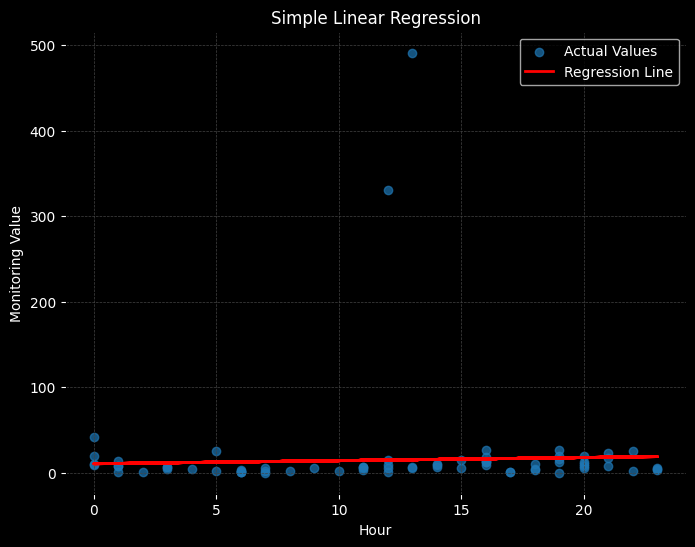

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_test_simple["Hour"],
    y_test,
    alpha=0.7,
    label="Actual Values"
)

plt.plot(
    X_test_simple["Hour"],
    simple_predictions,
    color="red",
    linewidth=2,
    label="Regression Line"
)

plt.title("Simple Linear Regression")

plt.xlabel("Hour")

plt.ylabel("Monitoring Value")

plt.legend()

plt.grid(True)

plt.show()
# Re-run to apply global plotting style.

## Actual vs Predicted Values for Simple Linear Regression

This visualization compares the actual monitoring values with the values predicted by the Simple Linear Regression model. A closer agreement between the two indicates better predictive performance.

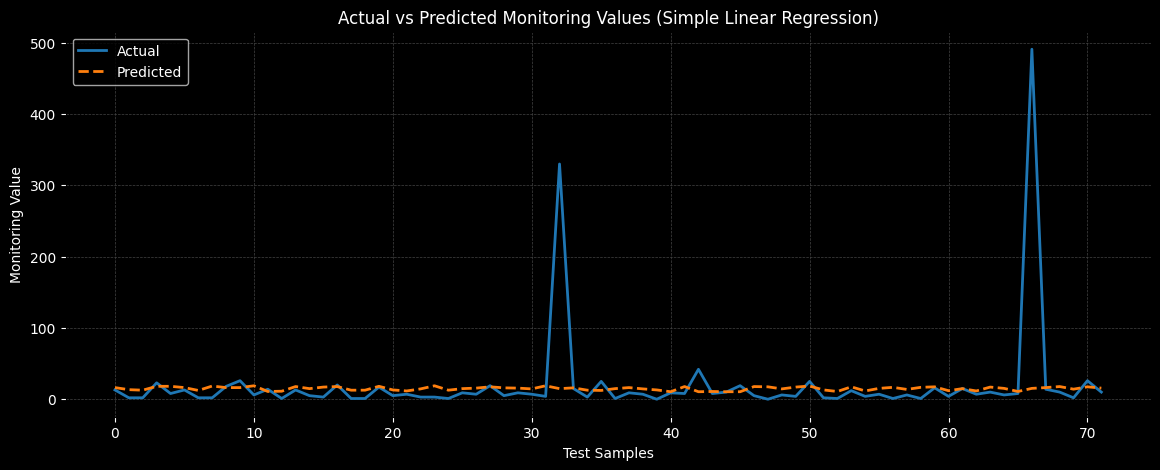

In [ ]:
comparison_simple = comparison_simple.sort_index()

plt.figure(figsize=(14,5))

plt.plot(
    comparison_simple.index,
    comparison_simple["Actual Value"],
    label="Actual",
    linewidth=2
)

plt.plot(
    comparison_simple.index,
    comparison_simple["Predicted Value"],
    linestyle="--",
    linewidth=2,
    label="Predicted"
)

plt.title("Actual vs Predicted Monitoring Values (Simple Linear Regression)")

plt.xlabel("Test Samples")

plt.ylabel("Monitoring Value")

plt.legend()

plt.grid(True)

plt.show()

## Actual vs Predicted Values for Multiple Linear Regression

This visualization compares the observed monitoring values with the predictions generated by the Multiple Linear Regression model. The comparison helps evaluate whether incorporating multiple features improves prediction quality.

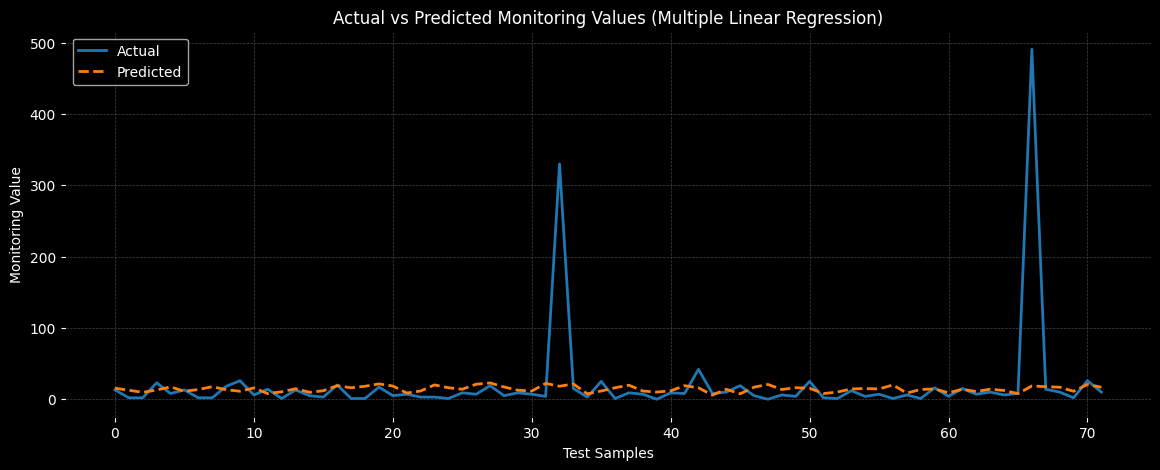

In [ ]:
comparison_multiple = comparison_multiple.sort_index()

plt.figure(figsize=(14,5))

plt.plot(
    comparison_multiple.index,
    comparison_multiple["Actual Value"],
    label="Actual",
    linewidth=2
)

plt.plot(
    comparison_multiple.index,
    comparison_multiple["Predicted Value"],
    linestyle="--",
    linewidth=2,
    label="Predicted"
)

plt.title("Actual vs Predicted Monitoring Values (Multiple Linear Regression)")

plt.xlabel("Test Samples")

plt.ylabel("Monitoring Value")

plt.legend()

plt.grid(True)

plt.show()

## Residual Analysis

Residuals represent the difference between the actual monitoring values and the predicted values. An effective regression model produces residuals that are randomly distributed around zero without any clear pattern.

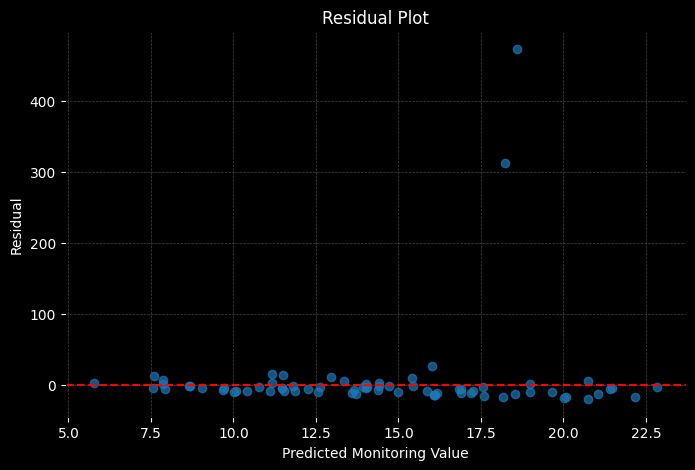

In [ ]:
residuals = y_test_multiple - multiple_predictions

plt.figure(figsize=(8,5))

plt.scatter(
    multiple_predictions,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.title("Residual Plot")

plt.xlabel("Predicted Monitoring Value")

plt.ylabel("Residual")

plt.grid(True)

plt.show()

## Regression Coefficient Analysis

Regression coefficients indicate the influence of each independent feature on the predicted monitoring value. Positive coefficients indicate a direct relationship, whereas negative coefficients indicate an inverse relationship.

In [ ]:
coefficient_df = pd.DataFrame({
    "Feature": X_multiple.columns,
    "Coefficient": multiple_lr.coef_
})

display(coefficient_df)

,Feature,Coefficient
0,Hour,0.359049
1,Minute,0.000000
2,Second,0.000000
3,DayOfWeek,-2.107472
4,IsWeekend,2.028384


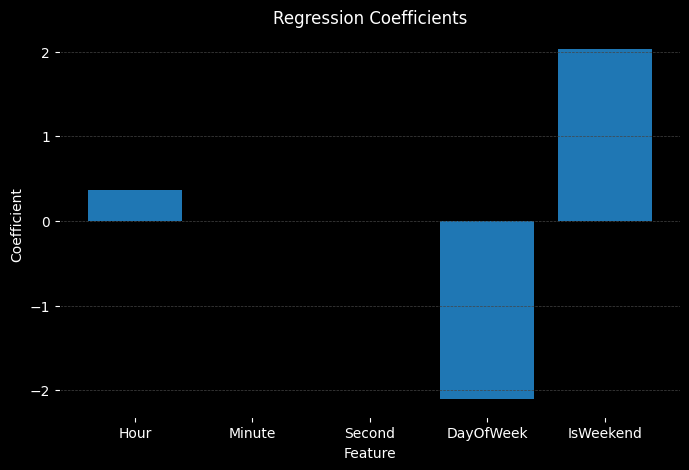

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    coefficient_df["Feature"],
    coefficient_df["Coefficient"]
)

plt.title("Regression Coefficients")

plt.xlabel("Feature")

plt.ylabel("Coefficient")

plt.grid(axis="y")

plt.show()

## Correlation Heatmap of Regression Features

The correlation heatmap illustrates the relationships among the numerical features used in the regression models. Strong positive or negative correlations may influence model behaviour and help in understanding feature dependencies.

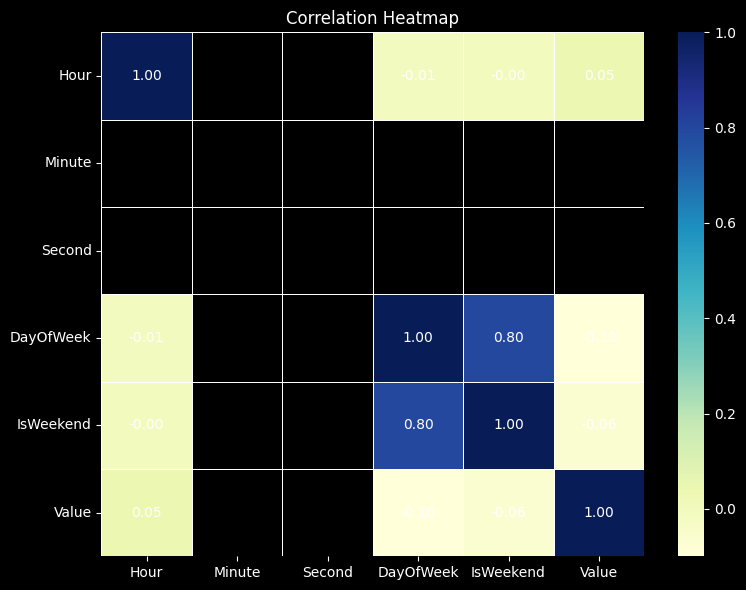

In [ ]:
regression_df = model_df[
    [
        "Hour",
        "Minute",
        "Second",
        "DayOfWeek",
        "IsWeekend",
        "Value"
    ]
]

correlation = regression_df.corr()

plt.figure(figsize=(8,6))

hm = sns.heatmap(
    correlation,
    annot=True,
    cmap="YlGnBu",
    linewidths=0.5,
    fmt=".2f",
    annot_kws={"color": "white"}
)

# Get the colorbar object from the heatmap
cbar = hm.collections[0].colorbar

# Set colorbar label and tick label colors
cbar.set_label(cbar.ax.get_ylabel(), color='white')
cbar.ax.yaxis.set_tick_params(colors='white')

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

## Comparison of Simple and Multiple Linear Regression Models

The following visualization compares the prediction performance of the Simple Linear Regression and Multiple Linear Regression models against the actual monitoring values. The diagonal reference line represents perfect predictions. Points closer to this line indicate better prediction accuracy, allowing a visual comparison of the two regression models.

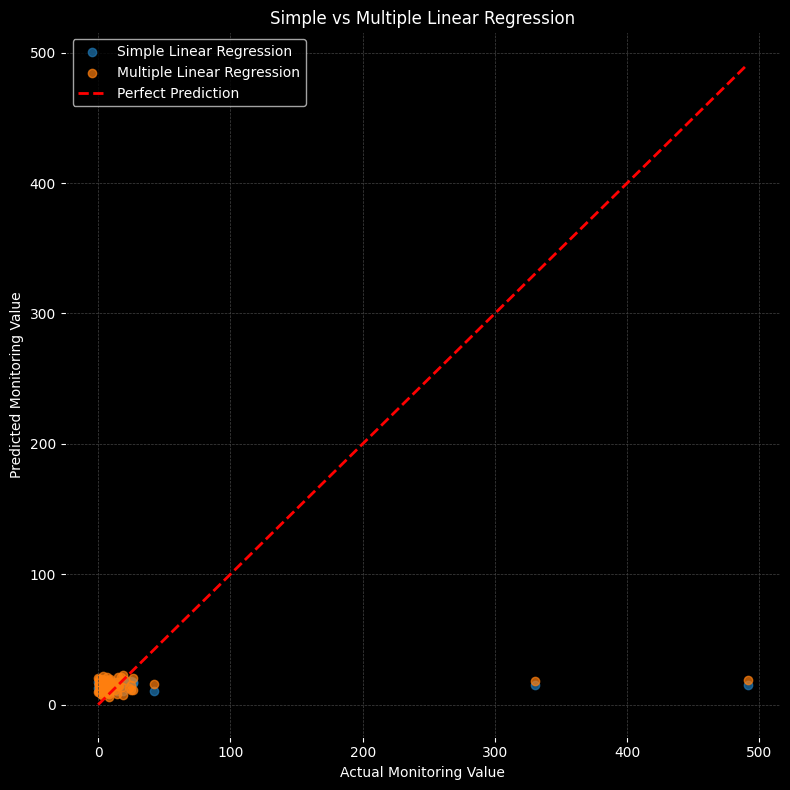

In [ ]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    simple_predictions,
    alpha=0.7,
    label="Simple Linear Regression"
)

plt.scatter(
    y_test_multiple,
    multiple_predictions,
    alpha=0.7,
    label="Multiple Linear Regression"
)

minimum = min(
    y_test.min(),
    y_test_multiple.min()
)

maximum = max(
    y_test.max(),
    y_test_multiple.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.title("Simple vs Multiple Linear Regression")

plt.xlabel("Actual Monitoring Value")

plt.ylabel("Predicted Monitoring Value")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

## Regression Model Interpretation

The Simple Linear Regression model predicts the monitoring value using only a single predictor, whereas the Multiple Linear Regression model utilizes multiple temporal features simultaneously. By comparing their evaluation metrics and visualizations, it is possible to assess whether the additional features improve prediction performance. Lower prediction errors (MAE, MSE, and RMSE) together with a higher R² Score indicate a more effective regression model. The regression coefficient analysis further explains the contribution of each predictor towards estimating the monitoring value.

## Key Observations

- The cloud monitoring dataset was successfully prepared for regression analysis.
- Temporal features extracted from the timestamp enabled the implementation of both Simple and Multiple Linear Regression models.
- Multiple Linear Regression utilized additional predictor variables to estimate the monitoring values.
- Regression performance was evaluated using MAE, MSE, RMSE, and R² Score.
- Regression visualizations helped compare prediction quality, residual behaviour, and feature contributions.
- Comparative analysis highlighted the differences between the two regression models and demonstrated the impact of using multiple predictor variables.

## Conclusion

In this laboratory experiment, Simple Linear Regression and Multiple Linear Regression models were successfully implemented using a real-world cloud infrastructure monitoring dataset. Temporal features were extracted from the monitoring timestamps and used to predict the application monitoring values. Both models were evaluated using standard regression metrics and multiple visualization techniques, enabling a detailed comparison of their predictive performance. The experiment demonstrated the complete regression workflow, including data preparation, model development, evaluation, and interpretation, thereby fulfilling the objective of implementing and comparing linear regression techniques on a real-world machine learning dataset.

In [ ]:
completion_checklist = pd.DataFrame({
    "Task": [
        "Imported required libraries",
        "Uploaded project datasets",
        "Extracted ZIP archives",
        "Configured dataset paths",
        "Loaded cloud monitoring dataset",
        "Prepared regression dataset",
        "Performed feature engineering",
        "Implemented Simple Linear Regression",
        "Implemented Multiple Linear Regression",
        "Generated predictions",
        "Evaluated regression models",
        "Compared regression performance",
        "Generated regression visualizations",
        "Interpreted regression results"
    ],
    "Status": ["✓ Completed"] * 14
})

display(completion_checklist)

,Task,Status
0,Imported required libraries,✓ Completed
1,Uploaded project datasets,✓ Completed
2,Extracted ZIP archives,✓ Completed
3,Configured dataset paths,✓ Completed
4,Loaded cloud monitoring dataset,✓ Completed
5,Prepared regression dataset,✓ Completed
6,Performed feature engineering,✓ Completed
7,Implemented Simple Linear Regression,✓ Completed
8,Implemented Multiple Linear Regression,✓ Completed
9,Generated predictions,✓ Completed


In [ ]:

print("              LINEAR REGRESSION EXPERIMENT SUMMARY")


print(f"Dataset Used                    : {selected_dataset.split('/')[-1]}")
print(f"Total Records                   : {len(model_df)}")
print(f"Target Variable                 : Value")
print(f"Simple Regression Feature       : Hour")
print(f"Multiple Regression Features    : Hour, Minute, Second, DayOfWeek, IsWeekend")

print("\nSimple Linear Regression")

print(f"MAE                             : {simple_mae:.4f}")
print(f"MSE                             : {simple_mse:.4f}")
print(f"RMSE                            : {simple_rmse:.4f}")
print(f"R² Score                        : {simple_r2:.4f}")

print("\nMultiple Linear Regression")

print(f"MAE                             : {multiple_mae:.4f}")
print(f"MSE                             : {multiple_mse:.4f}")
print(f"RMSE                            : {multiple_rmse:.4f}")
print(f"R² Score                        : {multiple_r2:.4f}")

if multiple_r2 > simple_r2:
    print("\nObservation : Multiple Linear Regression performed better than Simple Linear Regression.")
elif multiple_r2 < simple_r2:
    print("\nObservation : Simple Linear Regression performed better than Multiple Linear Regression.")
else:
    print("\nObservation : Both models achieved similar predictive performance.")

print("\nStatus : LAB 3 COMPLETED SUCCESSFULLY")



              LINEAR REGRESSION EXPERIMENT SUMMARY
Dataset Used                    : app1-01.csv
Total Records                   : 358
Target Variable                 : Value
Simple Regression Feature       : Hour
Multiple Regression Features    : Hour, Minute, Second, DayOfWeek, IsWeekend

Simple Linear Regression
MAE                             : 19.3131
MSE                             : 4620.8538
RMSE                            : 67.9769
R² Score                        : -0.0055

Multiple Linear Regression
MAE                             : 19.1136
MSE                             : 4547.7276
RMSE                            : 67.4368
R² Score                        : 0.0104

Observation : Multiple Linear Regression performed better than Simple Linear Regression.

Status : LAB 3 COMPLETED SUCCESSFULLY
